In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))

# Any results you write to the current directory are saved as output.

bitcoin-cash-price
cryptocurrencypricehistory



In [2]:
# Import Packages
import warnings
warnings.filterwarnings('ignore')
import numpy as np 
import pandas as pd 
from pandas import DataFrame
import matplotlib.pyplot as plt

#importing packages for the prediction of time-series data
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf

from sklearn.metrics import mean_squared_error

%matplotlib inline

In [3]:
df = pd.read_csv('/kaggle/input/bitcoin-cash-price/bitcoin_cash_price.csv', parse_dates=['Date'])
df.head(3)

,Date,Open,High,Low,Close,Volume,Market Cap
0,2017-11-07,602.68,626.21,602.45,616.30,"375,367,000","10,105,200,000"
1,2017-11-06,630.31,657.34,602.65,602.65,"794,105,000","10,566,600,000"
2,2017-11-05,619.91,635.72,579.13,630.70,"816,028,000","10,390,900,000"


**Initial Inspections**

In [4]:
print (df.describe())
print ("=============================================================")
print (df.dtypes)

                      Date        Open         High         Low       Close
count                  108  108.000000   108.000000  108.000000  108.000000
mean   2017-09-14 12:00:00  443.794352   485.492778  410.065556  443.399630
min    2017-07-23 00:00:00  212.180000   223.700000  200.980000  213.150000
25%    2017-08-18 18:00:00  331.807500   360.725000  312.022500  332.012500
50%    2017-09-14 12:00:00  421.130000   452.525000  399.255000  421.110000
75%    2017-10-11 06:00:00  542.580000   600.397500  507.387500  543.150000
max    2017-11-07 00:00:00  772.420000  1091.970000  683.940000  754.560000
std                    NaN  125.975442   147.717703  119.057755  126.029183
Date          datetime64[ns]
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume                object
Market Cap            object
dtype: object


Lets segregate the Date & Close price to analyze them separately

In [5]:
df1 = df[['Date','Close']]
df1.head(3)

,Date,Close
0,2017-11-07,616.30
1,2017-11-06,602.65
2,2017-11-05,630.70


In [6]:
# Setting the Date as Index
df_ts = df1.set_index('Date')
df_ts.sort_index(inplace=True)
print (type(df_ts))
print (df_ts.head(3))
print ("========================")
print (df_ts.tail(3))

<class 'pandas.core.frame.DataFrame'>
             Close
Date              
2017-07-23  413.06
2017-07-24  440.70
2017-07-25  406.90
             Close
Date              
2017-11-05  630.70
2017-11-06  602.65
2017-11-07  616.30


<Axes: xlabel='Date'>

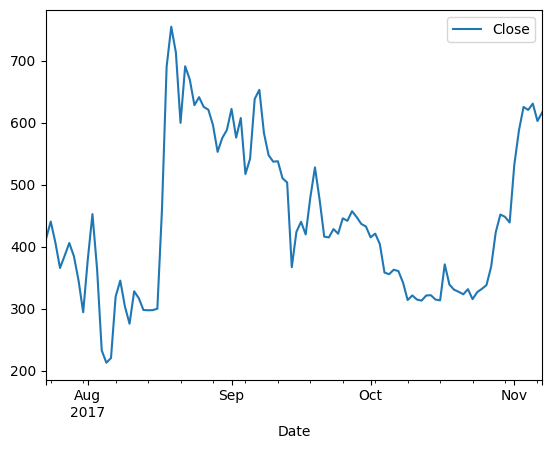

In [7]:
# Basic plot 
df_ts.plot()

In [8]:
# Dickey Fuller Test Function
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    from statsmodels.tsa.stattools import adfuller
    print('Results of Dickey-Fuller Test:')
    print ("==============================================")
    
    dftest = adfuller(timeseries, autolag='AIC')
    
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#lags Used', 'Number of Observations Used'])
    
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    
    print(dfoutput)
    

In [9]:
# Stationarity Check - Lets do a quick check on Stationarity with Dickey Fuller Test 
# Convert the DF to series first
ts = df_ts['Close']
test_stationarity(ts)


Results of Dickey-Fuller Test:
Test Statistic                  -2.461179
p-value                          0.125208
#lags Used                       1.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


**Conclusion **

The Test Statistics value is Much higher than critical value. So we can't reject the Null Hypothesis.

Hence Statistically (and obviously from the plot) the Time series is Non-Stationary


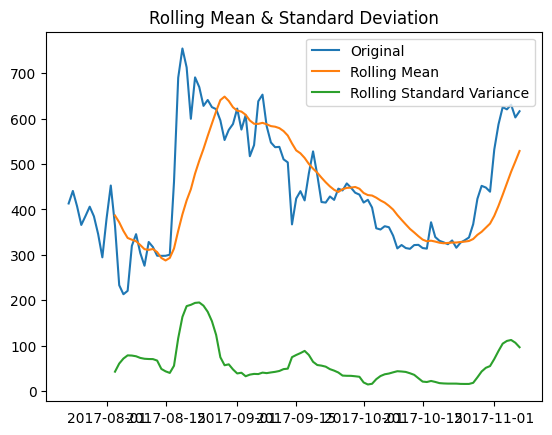

In [10]:
# Let's plot the 12-Month Moving Rolling Mean & Variance and find Insights
# Rolling Statistics
rolmean = ts.rolling(window=12).mean()
rolvar = ts.rolling(window=12).std()

plt.plot(ts, label='Original')
plt.plot(rolmean, label='Rolling Mean')
plt.plot(rolvar, label='Rolling Standard Variance')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

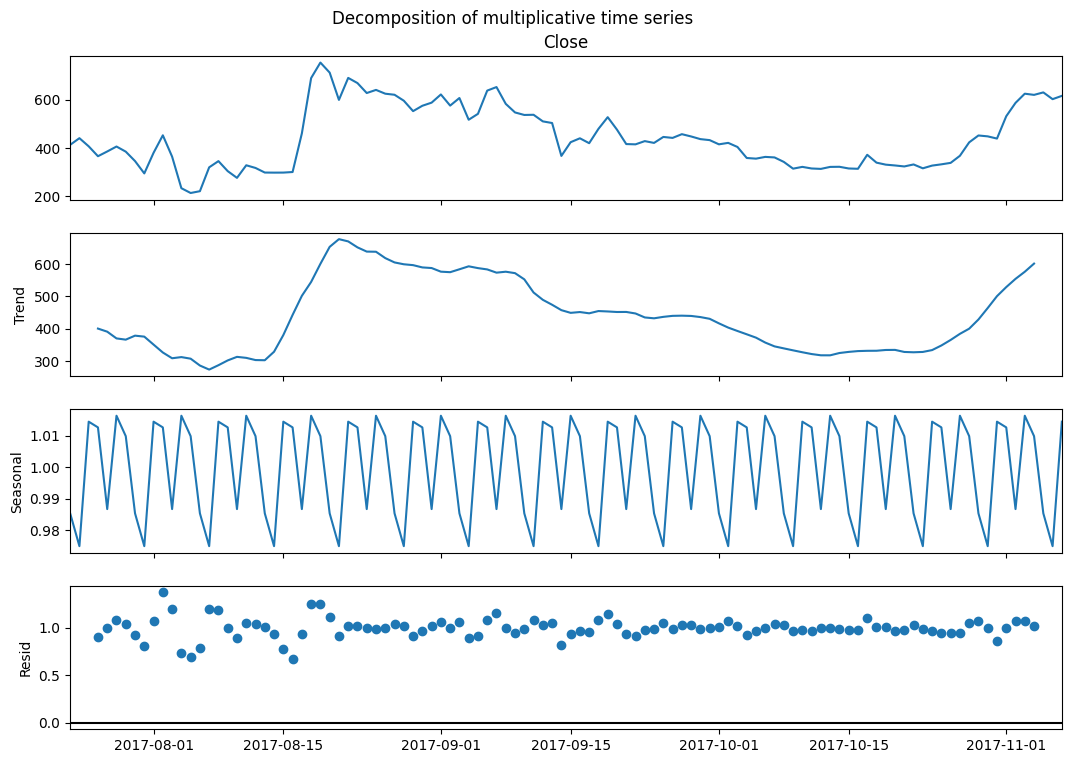

In [11]:
# Lets do a quick vanila decomposition to see any trend seasonality etc in the ts
decomposition = sm.tsa.seasonal_decompose(ts, model='multiplicative')

fig = decomposition.plot()
fig.set_figwidth(12)
fig.set_figheight(8)
fig.suptitle('Decomposition of multiplicative time series')
plt.show()

**Conslusion**

Seasonal graph is too stacked - leaving us quite unequipped to sight anything specific. This was obvious by the way since we are analyzing daily data.

Let's try out a Monthly approach

In [12]:
# Lets Resample the data by Month and analyze again
df_ts_m = df_ts.resample('M').mean()
print (type(df_ts_m))
print (df_ts_m.head(3))

<class 'pandas.core.frame.DataFrame'>
                 Close
Date                  
2017-07-31  382.544444
2017-08-31  463.022903
2017-09-30  495.079333


In [13]:
tsm = df_ts_m['Close']
print (type(tsm))

<class 'pandas.core.series.Series'>


In [14]:
# Stationarity Check
test_stationarity(tsm)

Results of Dickey-Fuller Test:
Test Statistic                -3.357436
p-value                        0.012498
#lags Used                     0.000000
Number of Observations Used    4.000000
Critical Value (1%)           -7.355441
Critical Value (5%)           -4.474365
Critical Value (10%)          -3.126933
dtype: float64


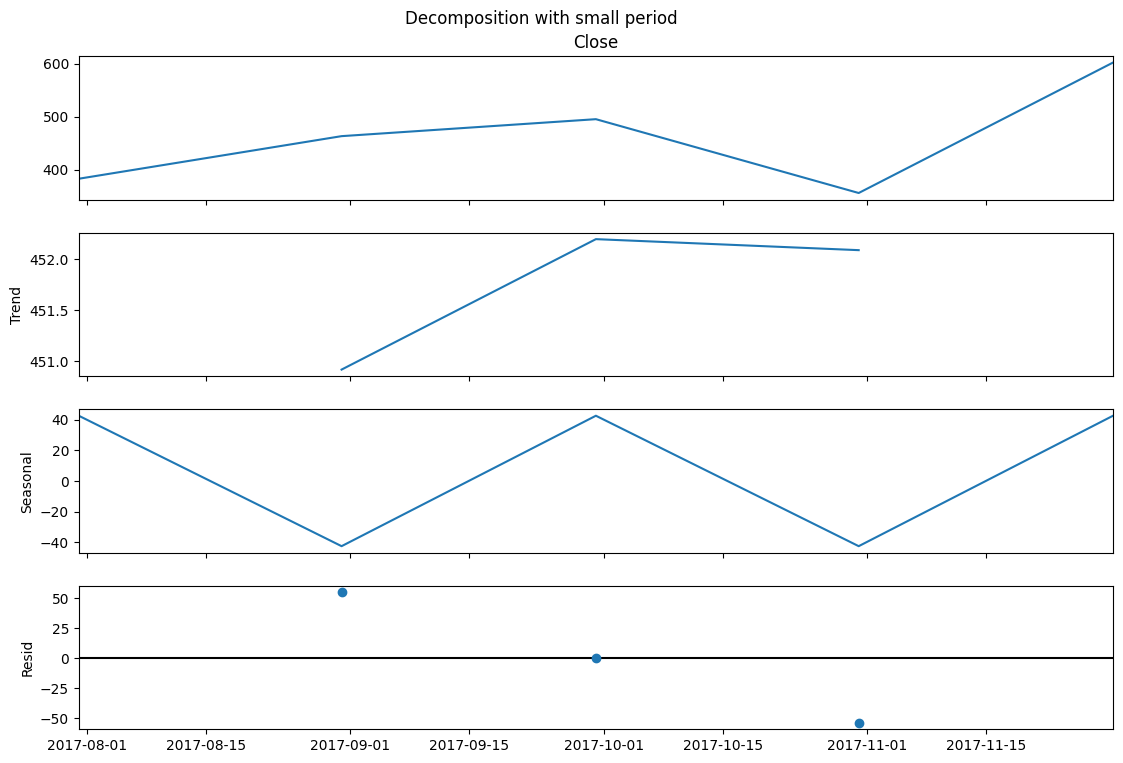

In [15]:
# Use additive model and manually specify a smaller seasonal period
decomposition = sm.tsa.seasonal_decompose(tsm, model='additive', period=2)

fig = decomposition.plot()
fig.set_figwidth(12)
fig.set_figheight(8)
fig.suptitle('Decomposition with small period')
plt.show()

**Conclusion**

This we see a somewhat clarity on the Seasonality graph

In [16]:
# lets try to make the "tsm" Stationary

tsmlog = np.log10(tsm)
tsmlog.dropna(inplace=True)

tsmlogdiff = tsmlog.diff(periods=1)
tsmlogdiff.dropna(inplace=True)
# Stationarity Check
test_stationarity(tsmlogdiff)

Results of Dickey-Fuller Test:
Test Statistic                 -2.133153
p-value                         0.231394
#lags Used                      0.000000
Number of Observations Used     3.000000
Critical Value (1%)           -10.417191
Critical Value (5%)            -5.778381
Critical Value (10%)           -3.391681
dtype: float64


**Conclusion**

Now the Test Statistics is less than Critical value - rendering that The time series is Stationary now. 
We can use it now in Forecasting Techniques like ARIMA